# Задача №1: подготовка датасета и EDA временного ряда Electricity


Основной временной ряд — `Consumption`, то есть потребление электроэнергии. Временная метка — `DateTime`. Данные приводятся к регулярной почасовой сетке, после чего выполняются базовый EDA, выделение train/test-выборок, первичный поиск аномалий и расчёт простого бейзлайна Seasonal Naive.

In [1]:
import sys
print(sys.executable)

c:\Users\CatandFox\AppData\Local\Programs\Python\Python311\python.exe


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


DATA_PATH = Path("../data/raw/Electricity.csv")
TARGET = "Consumption" # целевая переменная
DT = "DateTime"

## 1. Загрузка данных


In [3]:
df_raw = pd.read_csv(DATA_PATH)
df_raw.head(), df_raw.shape, df_raw.dtypes

(              DateTime  Consumption  Production  Nuclear  Wind  Hydroelectric  \
 0  2019-01-01 00:00:00         6352        6527     1395    79           1383   
 1  2019-01-01 01:00:00         6116        5701     1393    96           1112   
 2  2019-01-01 02:00:00         5873        5676     1393   142           1030   
 3  2019-01-01 03:00:00         5682        5603     1397   191            972   
 4  2019-01-01 04:00:00         5557        5454     1393   159            960   
 
    Oil and Gas  Coal  Solar  Biomass  
 0         1896  1744      0       30  
 1         1429  1641      0       30  
 2         1465  1616      0       30  
 3         1455  1558      0       30  
 4         1454  1458      0       30  ,
 (46011, 10),
 DateTime           str
 Consumption      int64
 Production       int64
 Nuclear          int64
 Wind             int64
 Hydroelectric    int64
 Oil and Gas      int64
 Coal             int64
 Solar            int64
 Biomass          int64
 dtype: obj

## 2. Подготовка временной оси и регулярной сетки

In [4]:
# Создание копии исходных данных
df = df_raw.copy()

# Преобразование временной метки в формат datetime
df[DT] = pd.to_datetime(df[DT])

# Пробразование столбцов (кроме DT) в числовые.
num_cols = [c for c in df.columns if c != DT]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Проверка дубликатов временных меток и сортировка данных по времени.
duplicates = df[DT].duplicated().sum()
df = df.sort_values(DT).groupby(DT, as_index=False)[num_cols].mean()

# Создание полной почасовой сетки от первой до последней даты.
full_idx = pd.date_range(df[DT].min(), df[DT].max(), freq="h")
missing_hours = len(full_idx) - len(df)

# Переиндексирование данных по полной сетке и заполненеие возможных пропусков.
df = df.set_index(DT).reindex(full_idx)
df.index.name = DT
for c in num_cols:
    df[c] = df[c].interpolate(method="time").ffill().bfill()
df = df.reset_index()

# Добавление календарных признаков
df["hour"] = df[DT].dt.hour
df["dayofweek"] = df[DT].dt.dayofweek
df["month"] = df[DT].dt.month
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
df["year"] = df[DT].dt.year

print("Дубликаты временных меток:", duplicates)
print("Пропущенные часы:", missing_hours)
print(df.shape)
df.head()

Дубликаты временных меток: 9
Пропущенные часы: 6
(46008, 15)


,DateTime,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass,hour,dayofweek,month,is_weekend,year
0,2019-01-01 00:00:00,6352.0,6527.0,1395.0,79.0,1383.0,1896.0,1744.0,0.0,30.0,0,1,1,0,2019
1,2019-01-01 01:00:00,6116.0,5701.0,1393.0,96.0,1112.0,1429.0,1641.0,0.0,30.0,1,1,1,0,2019
2,2019-01-01 02:00:00,5873.0,5676.0,1393.0,142.0,1030.0,1465.0,1616.0,0.0,30.0,2,1,1,0,2019
3,2019-01-01 03:00:00,5682.0,5603.0,1397.0,191.0,972.0,1455.0,1558.0,0.0,30.0,3,1,1,0,2019
4,2019-01-01 04:00:00,5557.0,5454.0,1393.0,159.0,960.0,1454.0,1458.0,0.0,30.0,4,1,1,0,2019


## 3. Разделение на тренировочную и тестовую выборки


In [5]:
split_idx = int(len(df) * 0.8)
df_split = df.copy()
df_split["split"] = "train"
df_split.loc[split_idx:, "split"] = "test"
train = df_split.iloc[:split_idx].copy()
test = df_split.iloc[split_idx:].copy()

print("train:", train[DT].min(), "—", train[DT].max(), train.shape)
print("test:", test[DT].min(), "—", test[DT].max(), test.shape)

train: 2019-01-01 00:00:00 — 2023-03-14 13:00:00 (36806, 16)
test: 2023-03-14 14:00:00 — 2024-03-31 23:00:00 (9202, 16)


## 4. EDA: динамика и сезонность

В этом разделе выполняется первичный анализ временного ряда `Consumption`.

Сначала строится график потребления во времени, чтобы оценить общий характер ряда: тренд, изменения уровня, возможные резкие скачки и неоднородность поведения на разных участках. Затем рассчитывается описательная статистика.

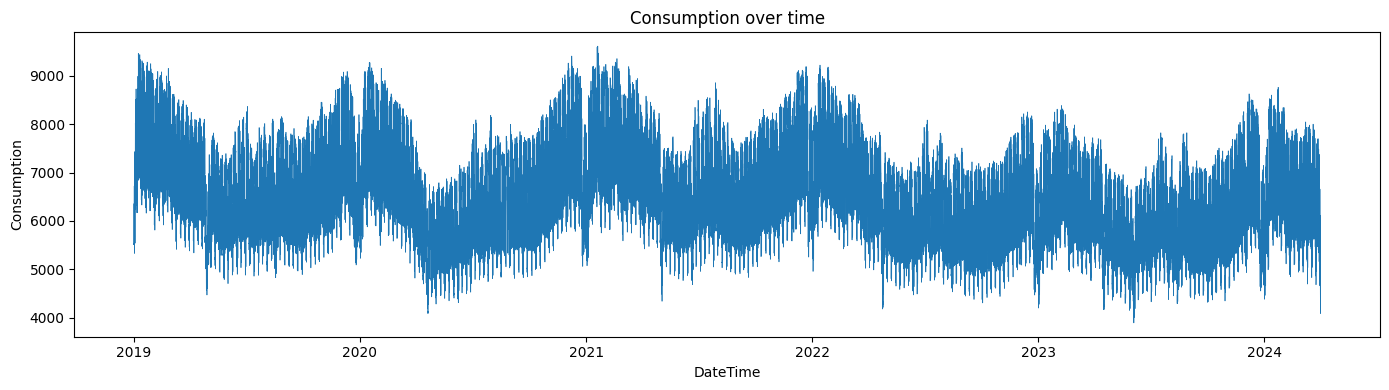

count    46008.000000
mean      6587.755948
std       1043.573742
min       3889.000000
25%       5773.000000
50%       6552.000000
75%       7321.000000
max       9615.000000
Name: Consumption, dtype: float64


In [6]:
fig_dir = Path("../reports/figures")
fig_dir.mkdir(parents=True, exist_ok=True)

# Строим график целевого ряда во времени.
plt.figure(figsize=(14, 4))
plt.plot(df[DT], df[TARGET], linewidth=0.5)
plt.title("Consumption over time")
plt.xlabel("DateTime")
plt.ylabel(TARGET)
plt.tight_layout()
plt.show()

# Базовая описательная статистика по целевой переменной.
print(df[TARGET].describe())

In [7]:
# Среднее потребление по часу суток, дню недели и месяцу.
hourly = df.groupby("hour")[TARGET].mean()
weekly = df.groupby("dayofweek")[TARGET].mean()
monthly = df.groupby("month")[TARGET].mean()

display(hourly.to_frame("mean_consumption"))
display(weekly.to_frame("mean_consumption"))
display(monthly.to_frame("mean_consumption"))

,mean_consumption
hour,
0,5862.199270
1,5653.457486
2,5536.318727
3,5485.799513
4,5515.098592
5,5626.234742
6,5949.989045
7,6511.368805
8,6940.532081


,mean_consumption
dayofweek,
0,6637.362332
1,6845.635341
2,6875.603558
3,6875.098844
4,6814.832725
5,6298.403437
6,5767.536446


,mean_consumption
month,
1,7239.078629
2,7165.422794
3,6777.522513
4,6300.157500
5,5988.722581
6,6150.920278
7,6487.788710
8,6353.122581
9,6163.162500


## 5. Первичный анализ аномалий

Для поиска потенциальных аномалий используется подход через сезонный остаток и robust z-score.
Сначала для каждого часа суток на обучающей выборке считается типичное медианное значение потребления. Затем из фактических значений вычитается соответствующее часовое медианное значение.

Далее рассчитывается robust z-score на основе медианы и MAD. Наблюдения с большим абсолютным значением robust z-score помечаются как потенциальные аномалии.

In [8]:
# Оцениваем типичный уровень потребления для каждого часа суток по тренировочной выборке.
seasonal_hour = train.groupby("hour")[TARGET].median()

# Убираем суточную сезонность
resid = df[TARGET] - df["hour"].map(seasonal_hour)

# Robust z-score считается через медиану и MAD
med = np.median(resid)
mad = np.median(np.abs(resid - med))
robust_z = 0.6745 * (resid - med) / mad

# Формирование таблицы потенциальных аномалий.
anom = df[[DT, TARGET]].copy()
anom["seasonal_residual"] = resid
anom["robust_z"] = robust_z
anom["is_anomaly_robust_z3_5"] = (np.abs(robust_z) > 3.5).astype(int)

print("Количество аномалий:", anom["is_anomaly_robust_z3_5"].sum())
anom.loc[anom["is_anomaly_robust_z3_5"] == 1].head()

Количество аномалий: 90


,DateTime,Consumption,seasonal_residual,robust_z,is_anomaly_robust_z3_5
8951,2020-01-08 23:00:00,8916.0,2616.0,3.557169,1
8952,2020-01-09 00:00:00,8916.0,2996.0,4.054858,1
8953,2020-01-09 01:00:00,8916.0,3207.0,4.331207,1
8954,2020-01-09 02:00:00,8916.0,3332.0,4.494920,1
8955,2020-01-09 03:00:00,8916.0,3397.5,4.580706,1


## 6. Бейзлайн Seasonal Naive

In [9]:
# Индексируем данные по времени
indexed = df_split.set_index(DT)

def seasonal_naive(test_df, lag):
    preds = []
    for t in test_df[DT]:
        src = t - pd.Timedelta(hours=lag)
        preds.append(indexed.loc[src, TARGET] if src in indexed.index else np.nan)
    return np.array(preds, dtype=float)

def evaluate(y, yhat):
    mask = np.isfinite(y) & np.isfinite(yhat) & (y != 0)
    y, yhat = y[mask], yhat[mask]
    return {
        "MAE": np.mean(np.abs(y-yhat)),
        "RMSE": np.sqrt(np.mean((y-yhat)**2)),
        "sMAPE_%": np.mean(2*np.abs(y-yhat)/(np.abs(y)+np.abs(yhat))) * 100,
        "n": len(y)
    }

# Сравнение двух сезонных бейзлайнов: сутки назад и неделю назад.
y = test[TARGET].to_numpy(dtype=float)
metrics = []
for lag in [24, 168]:
    yhat = seasonal_naive(test, lag)
    row = evaluate(y, yhat)
    row["model"] = f"SeasonalNaive_{lag}h"
    metrics.append(row)

pd.DataFrame(metrics)[["model", "MAE", "RMSE", "sMAPE_%", "n"]]

,model,MAE,RMSE,sMAPE_%,n
0,SeasonalNaive_24h,407.538307,585.482277,6.827294,9202
1,SeasonalNaive_168h,343.829874,512.089420,5.620342,9202


## 7. Сохранение подготовленных файлов

После подготовки данных сохраняются следующие файлы:

- полный подготовленный датасет;
- отдельная обучающая выборка;
- отдельная тестовая выборка;
- таблица с найденными потенциальными аномалиями;
- метрики бейзлайна;
- прогноз бейзлайна на тестовой выборке.


In [11]:
# Сохранение подготовленных данных в структуру проекта.
out_dir = Path("../data/processed")
out_dir.mkdir(parents=True, exist_ok=True)

df.to_csv(out_dir / "electricity_prepared.csv", index=False)
train.to_csv(out_dir / "electricity_train.csv", index=False)
test.to_csv(out_dir / "electricity_test.csv", index=False)

print("Файлы сохранены")

Файлы сохранены


## 8. Вывод

Временной ряд `Consumption` был подготовлен к дальнейшему анализу и прогнозированию.

Основные итоги:

- данные приведены к регулярной почасовой сетке;
- временная ось отсортирована по `DateTime`;
- добавлены календарные признаки;
- выделены обучающая и тестовая выборки;
- проведён первичный EDA;
- выполнен базовый анализ аномалий;
- рассчитан бейзлайн Seasonal Naive;
